In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better looking plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

In [6]:
df=pd.read_csv("ai_dependency_career_anxiety_students.csv")

In [7]:
print("=== Dataset Shape ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("=== First 5 rows ===")
print(df.head(), "\n")

print("=== Column Names ===")
print(df.columns.tolist(), "\n")

print("=== Data Types ===")
print(df.dtypes, "\n")

=== Dataset Shape ===
Rows: 15000, Columns: 30

=== First 5 rows ===
  student_id  age  gender  degree_type                stream  year_of_study  \
0  STU_00001   25    Male  B.Tech/B.E.  Engineering (Non-CS)              3   
1  STU_00002   20  Female  B.Tech/B.E.  Engineering (Non-CS)              4   
2  STU_00003   25  Female          MBA                 CS/IT              1   
3  STU_00004   23    Male  B.Tech/B.E.                 CS/IT              1   
4  STU_00005   22  Female          MBA                 CS/IT              1   

  college_tier urban_or_rural  daily_ai_tool_usage_hrs primary_ai_tools_used  \
0       Tier 3          Rural                      0.3            Perplexity   
1       Tier 3          Urban                      1.9               ChatGPT   
2       Tier 3          Urban                      3.6                Gemini   
3       Tier 1          Urban                      4.1        GitHub Copilot   
4       Tier 1          Urban                      3.4  

In [8]:
print("=== Missing Values ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0], "\n")

=== Missing Values ===
                              Missing Count  Percentage
primary_ai_tools_used                  3215   21.433333
self_learning_hours_per_week            233    1.553333
social_media_hrs_per_day                210    1.400000
sleep_hours                             203    1.353333
seeks_career_counseling                 220    1.466667 



In [9]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values handled.\n")

Missing values handled.



C:\Users\FATHIMA LAYA\AppData\Local\Temp\ipykernel_21644\2828291831.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [10]:
print("=== Summary Statistics (Numerical) ===")
print(df.describe(), "\n")

=== Summary Statistics (Numerical) ===
                age  year_of_study  daily_ai_tool_usage_hrs  \
count  15000.000000   15000.000000             15000.000000   
mean      21.384533       2.100067                 2.013893   
std        2.005626       0.987650                 1.735977   
min       18.000000       1.000000                 0.000000   
25%       20.000000       1.000000                 0.400000   
50%       21.000000       2.000000                 1.800000   
75%       22.000000       3.000000                 3.200000   
max       28.000000       4.000000                 8.000000   

       ai_replaces_own_thinking_score  ai_dependency_score  \
count                    15000.000000         15000.000000   
mean                         2.987733             4.539133   
std                          1.311932             2.315115   
min                          1.000000             1.000000   
25%                          2.000000             3.000000   
50%                  

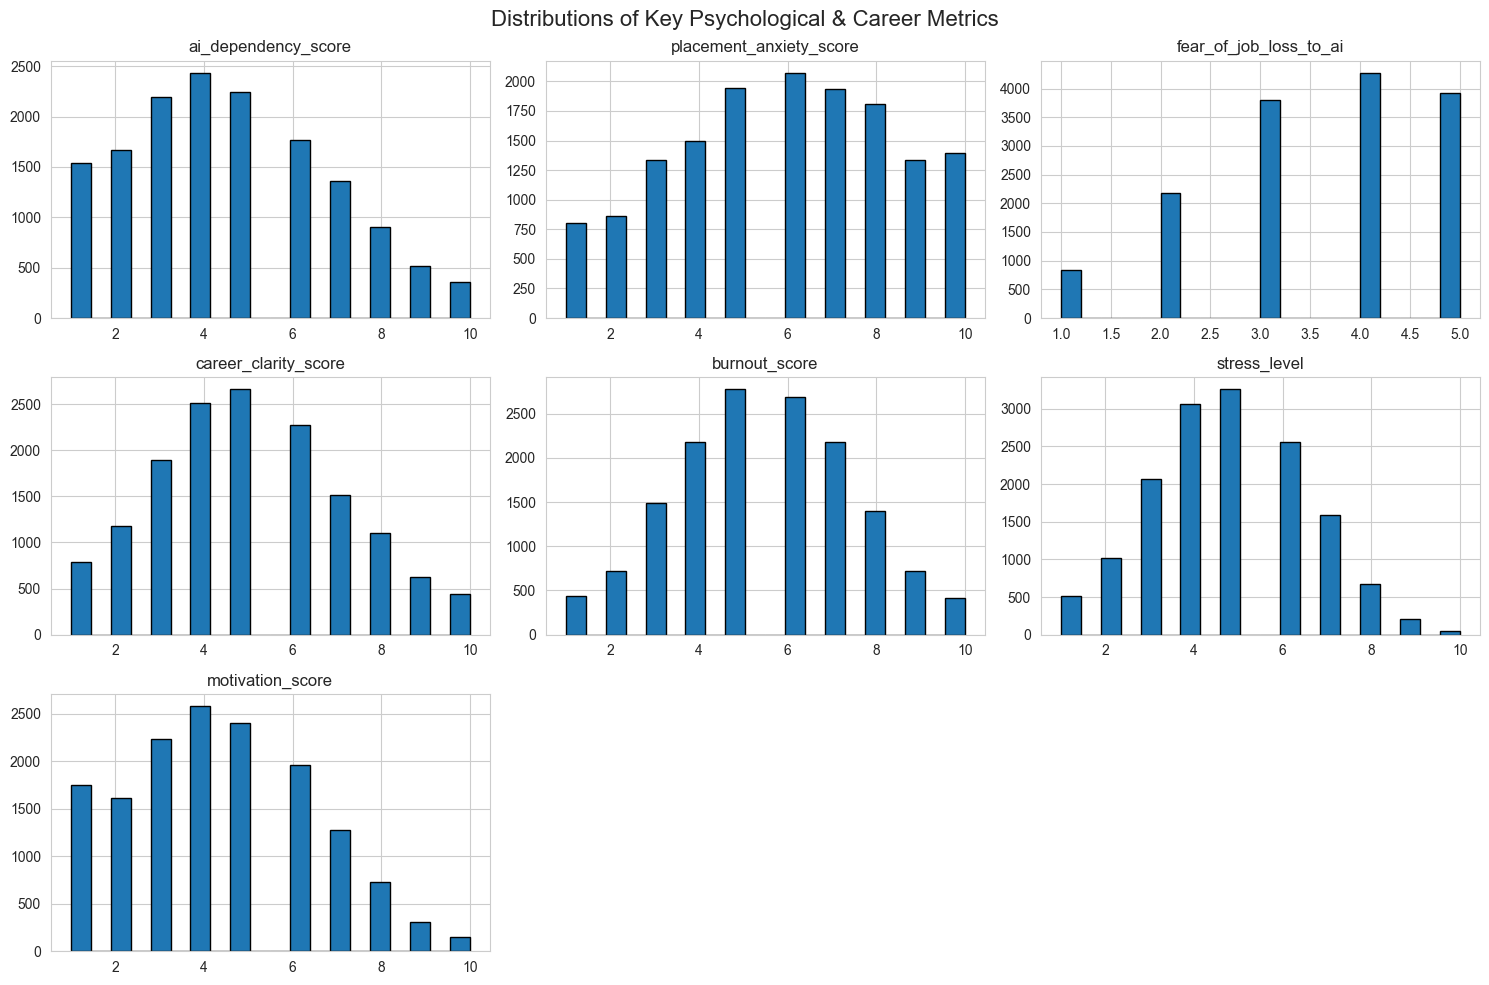

In [11]:
key_vars = ['ai_dependency_score', 'placement_anxiety_score', 'fear_of_job_loss_to_ai',
            'career_clarity_score', 'burnout_score', 'stress_level', 'motivation_score']

df[key_vars].hist(bins=20, figsize=(15, 10), edgecolor='black')
plt.suptitle("Distributions of Key Psychological & Career Metrics", fontsize=16)
plt.tight_layout()
plt.show()

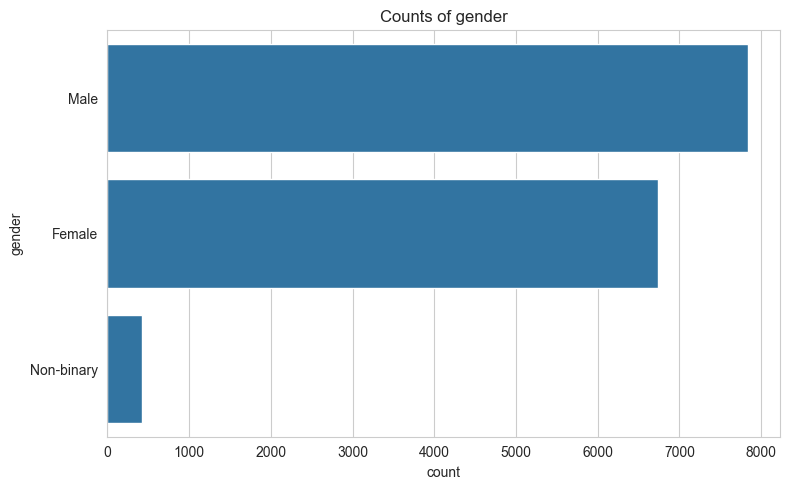

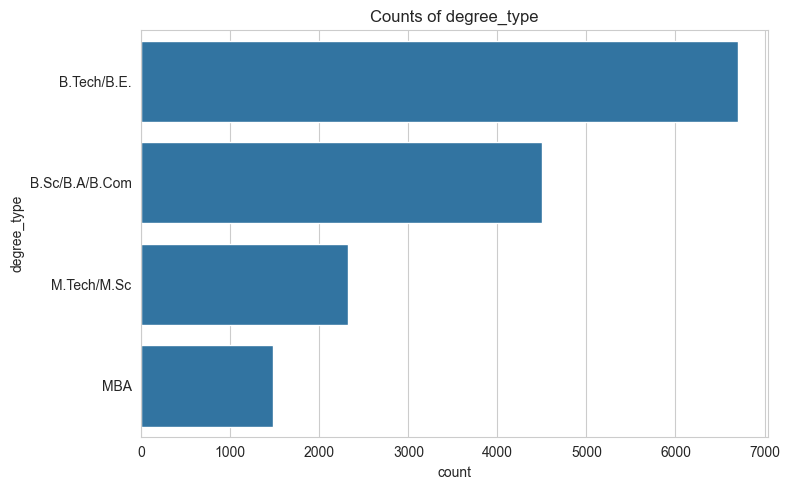

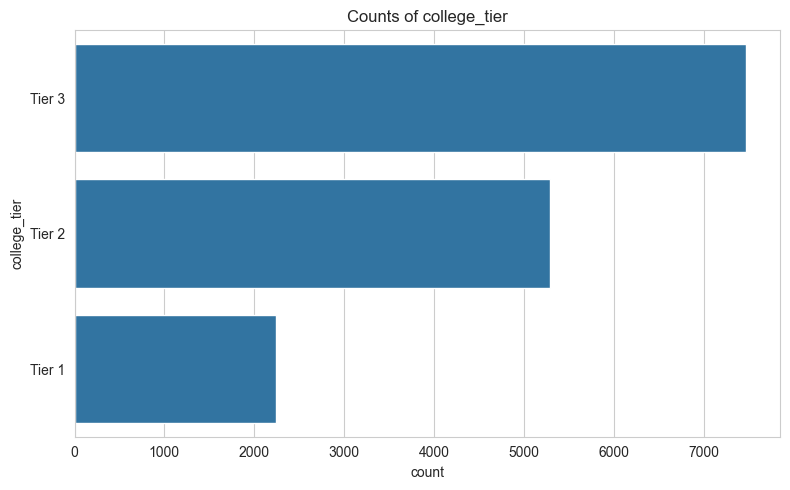

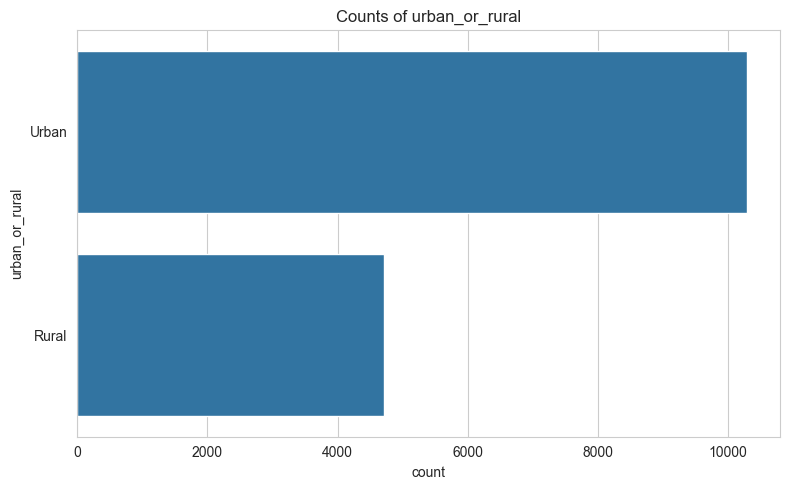

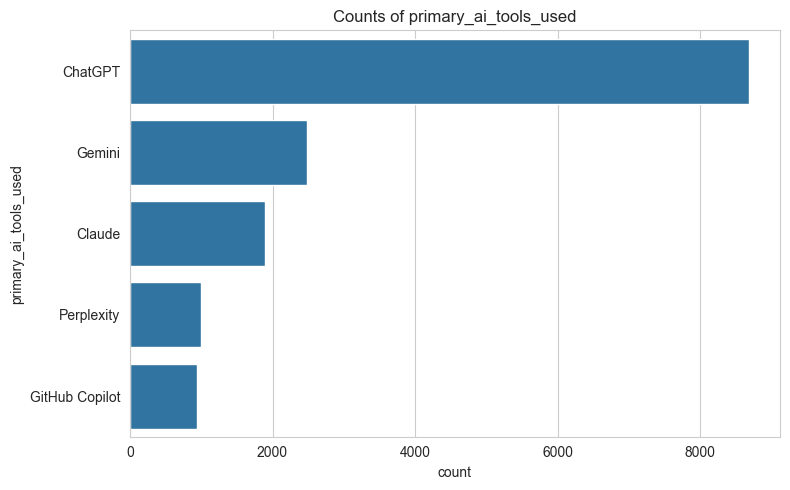

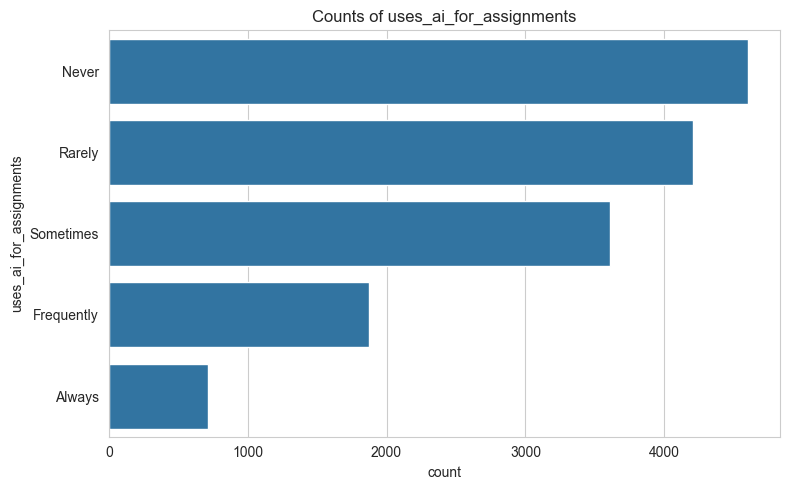

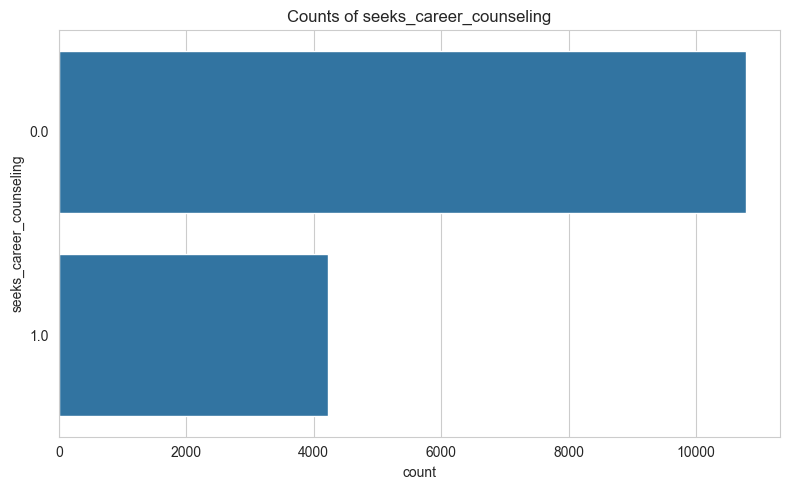

In [12]:
categorical_interest = ['gender', 'degree_type', 'college_tier', 'urban_or_rural', 
                        'primary_ai_tools_used', 'uses_ai_for_assignments', 'seeks_career_counseling']

for col in categorical_interest:
    if col in df.columns:
        plt.figure(figsize=(8, 5))
        sns.countplot(data=df, y=col, order=df[col].value_counts().index)
        plt.title(f"Counts of {col}")
        plt.tight_layout()
        plt.show()

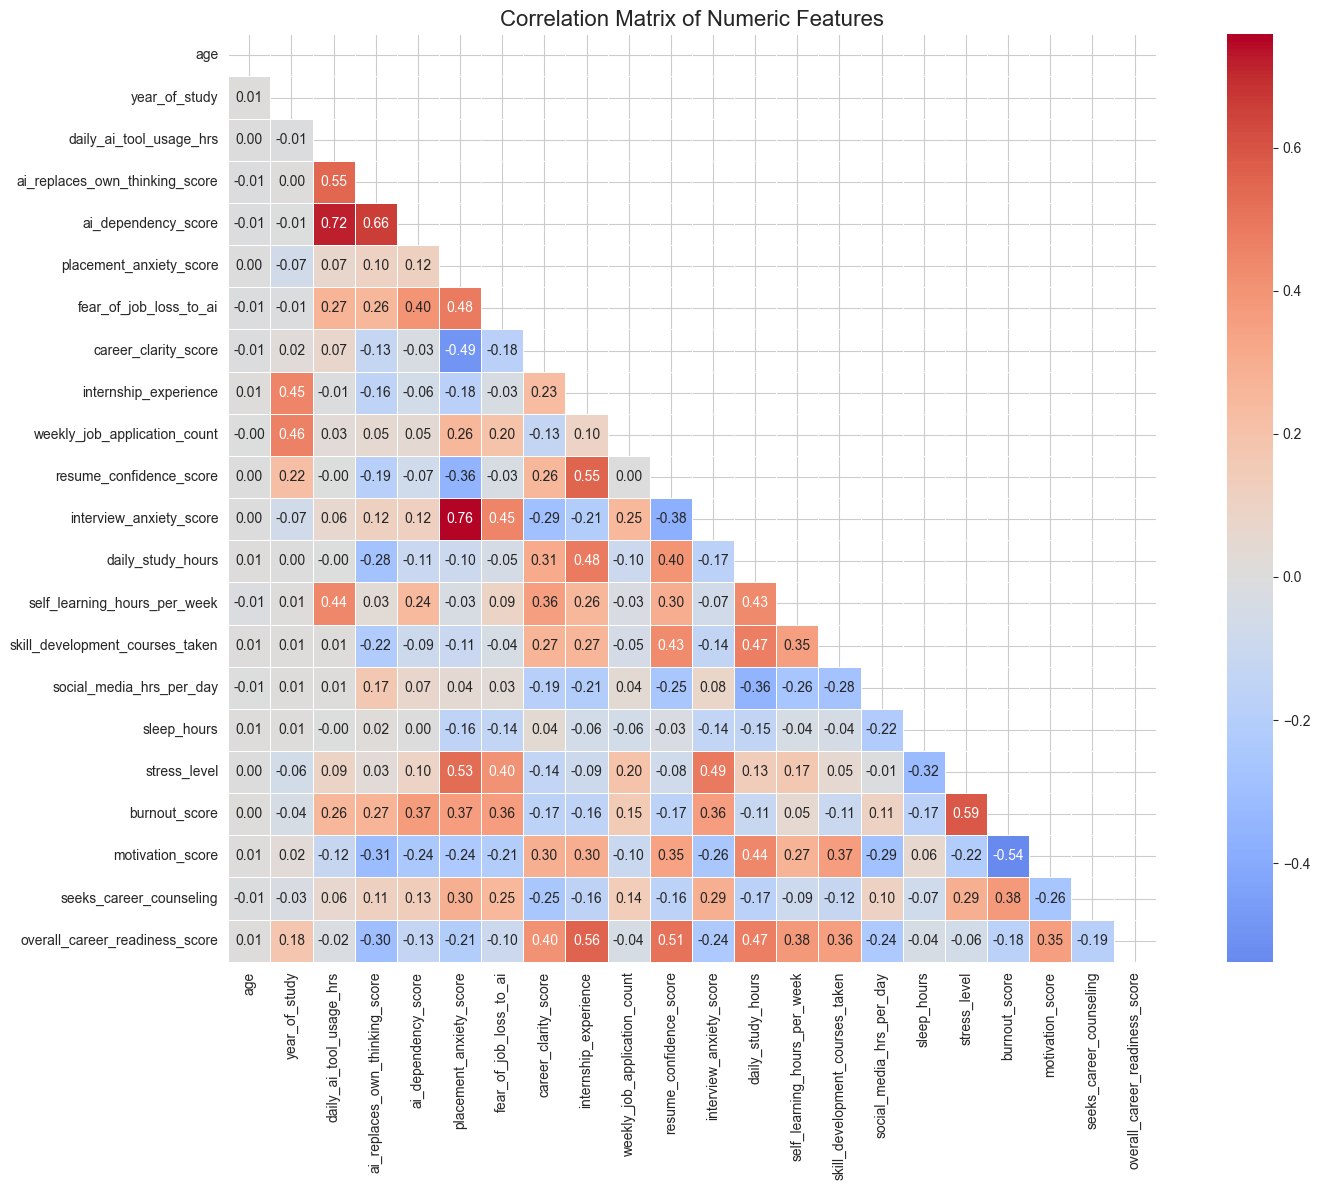

In [13]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", 
            linewidths=0.5, center=0, square=True)
plt.title("Correlation Matrix of Numeric Features", fontsize=16)
plt.tight_layout()
plt.show()


In [14]:
print("=== Top correlations with AI dependency score ===")
ai_corr = corr['ai_dependency_score'].sort_values(ascending=False)
print(ai_corr, "\n")

print("=== Top correlations with placement_anxiety_score ===")
anx_corr = corr['placement_anxiety_score'].sort_values(ascending=False)
print(anx_corr, "\n")


=== Top correlations with AI dependency score ===
ai_dependency_score                1.000000
daily_ai_tool_usage_hrs            0.716250
ai_replaces_own_thinking_score     0.658117
fear_of_job_loss_to_ai             0.401610
burnout_score                      0.369419
self_learning_hours_per_week       0.241029
seeks_career_counseling            0.131040
interview_anxiety_score            0.123681
placement_anxiety_score            0.118258
stress_level                       0.096018
social_media_hrs_per_day           0.067086
weekly_job_application_count       0.049301
sleep_hours                        0.001005
year_of_study                     -0.006130
age                               -0.008482
career_clarity_score              -0.034426
internship_experience             -0.059696
resume_confidence_score           -0.073227
skill_development_courses_taken   -0.088752
daily_study_hours                 -0.109157
overall_career_readiness_score    -0.131935
motivation_score          

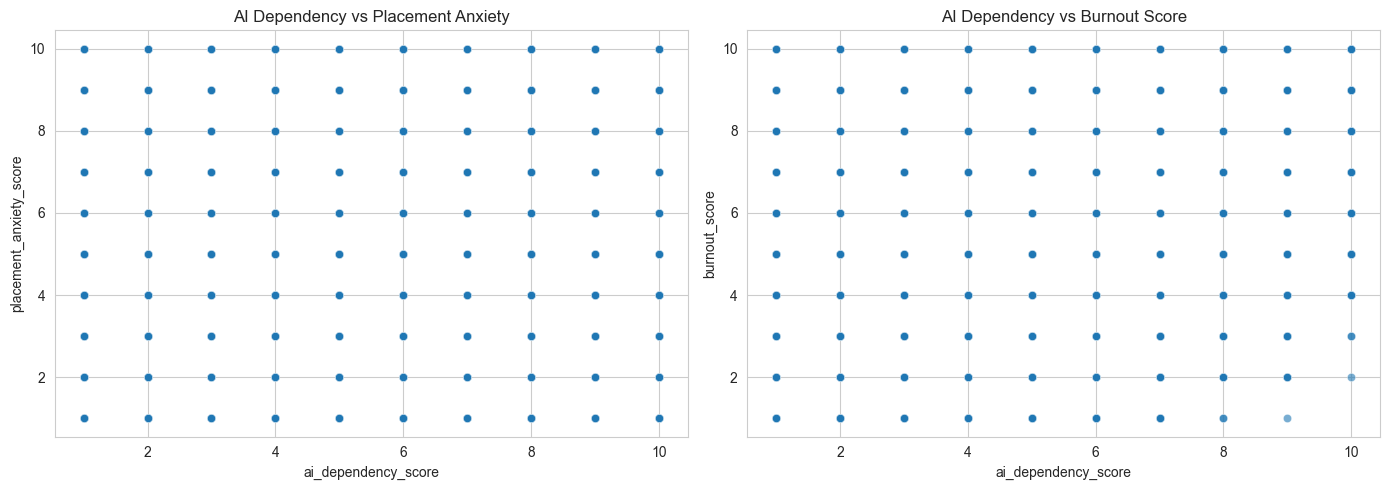

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x='ai_dependency_score', y='placement_anxiety_score', ax=axes[0], alpha=0.6)
axes[0].set_title("AI Dependency vs Placement Anxiety")
sns.scatterplot(data=df, x='ai_dependency_score', y='burnout_score', ax=axes[1], alpha=0.6)
axes[1].set_title("AI Dependency vs Burnout Score")
plt.tight_layout()
plt.show()

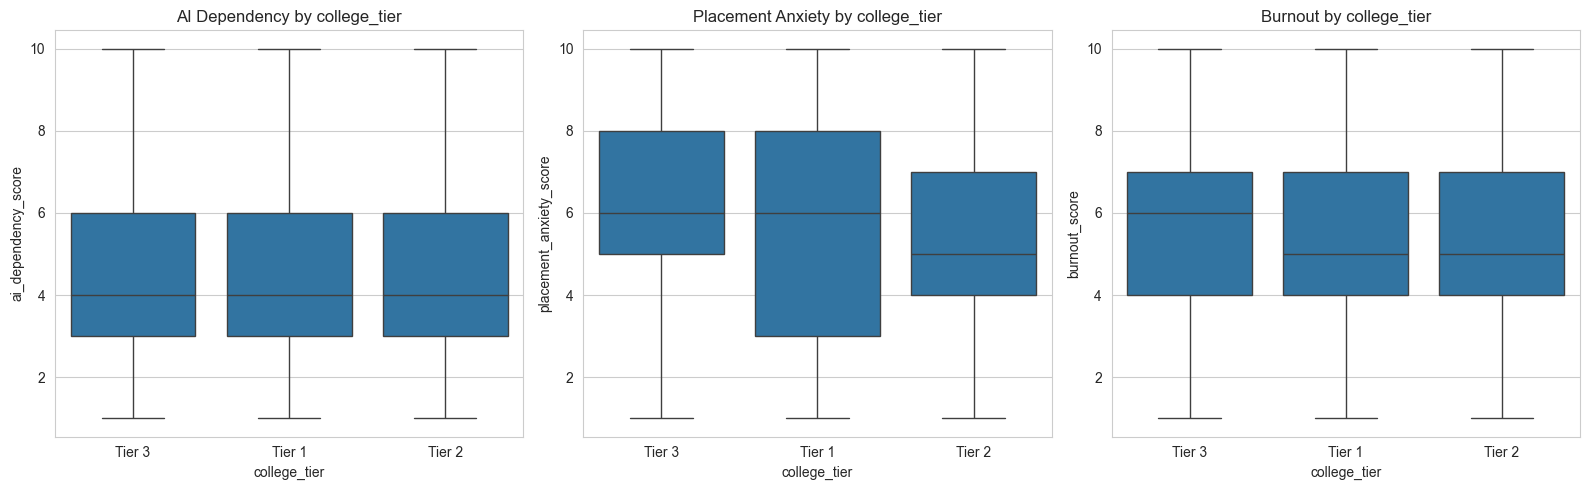

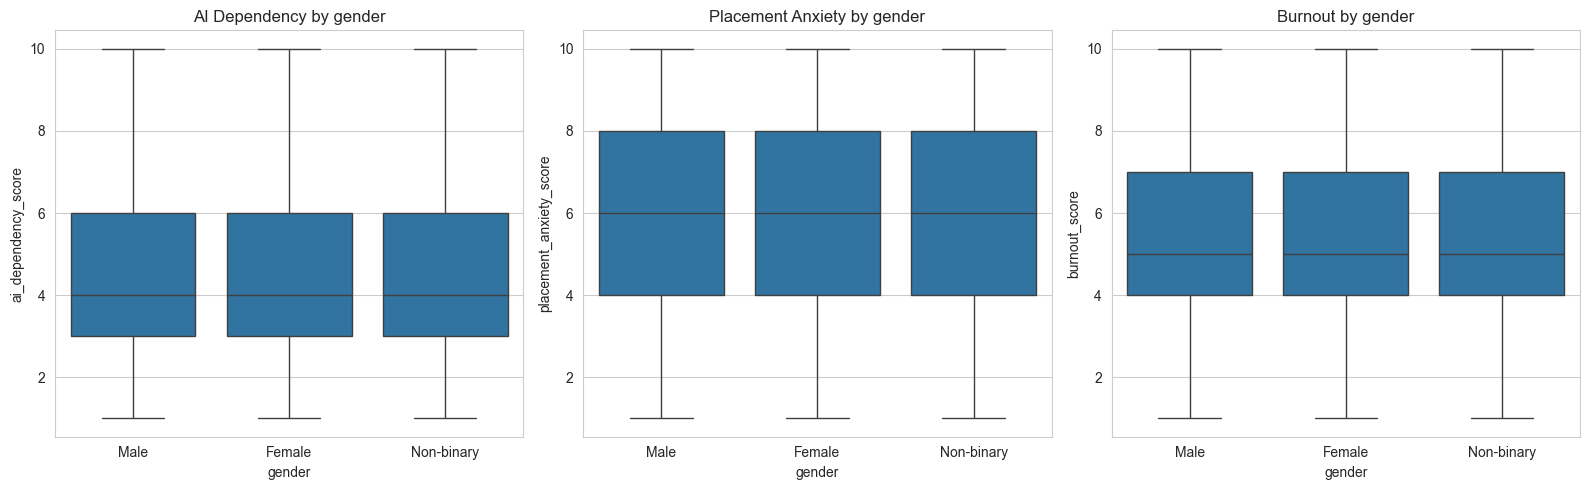

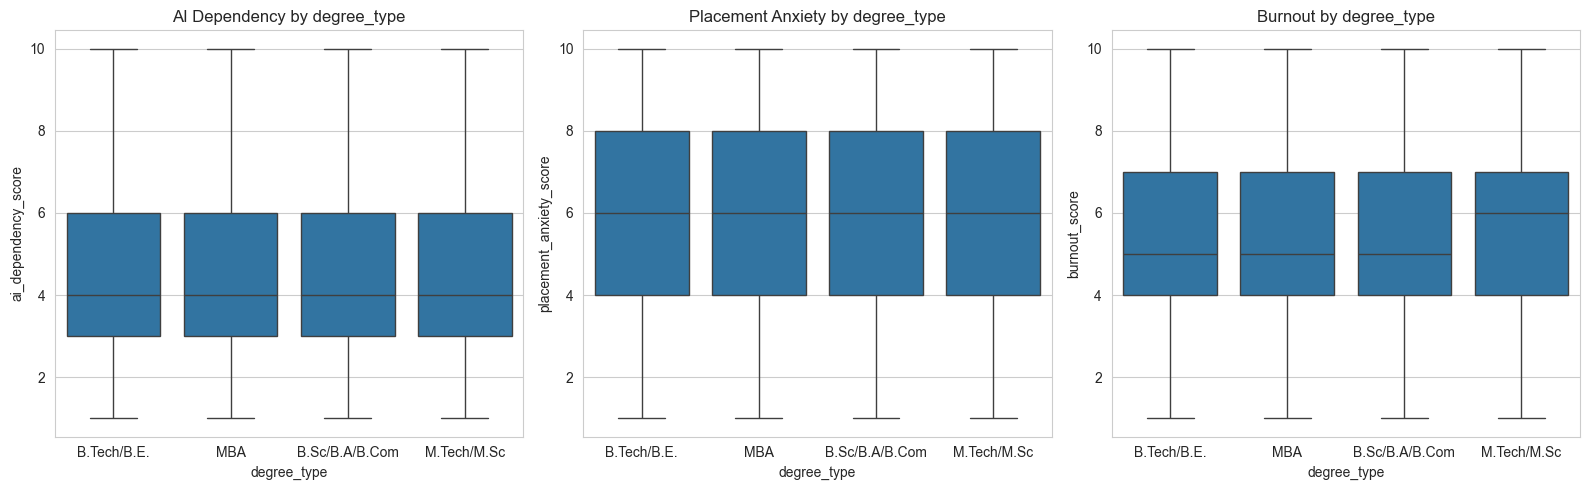

In [16]:
for col in ['college_tier', 'gender', 'degree_type']:
    if col in df.columns:
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        sns.boxplot(data=df, x=col, y='ai_dependency_score', ax=axes[0])
        axes[0].set_title(f"AI Dependency by {col}")
        sns.boxplot(data=df, x=col, y='placement_anxiety_score', ax=axes[1])
        axes[1].set_title(f"Placement Anxiety by {col}")
        sns.boxplot(data=df, x=col, y='burnout_score', ax=axes[2])
        axes[2].set_title(f"Burnout by {col}")
        plt.tight_layout()
        plt.show()

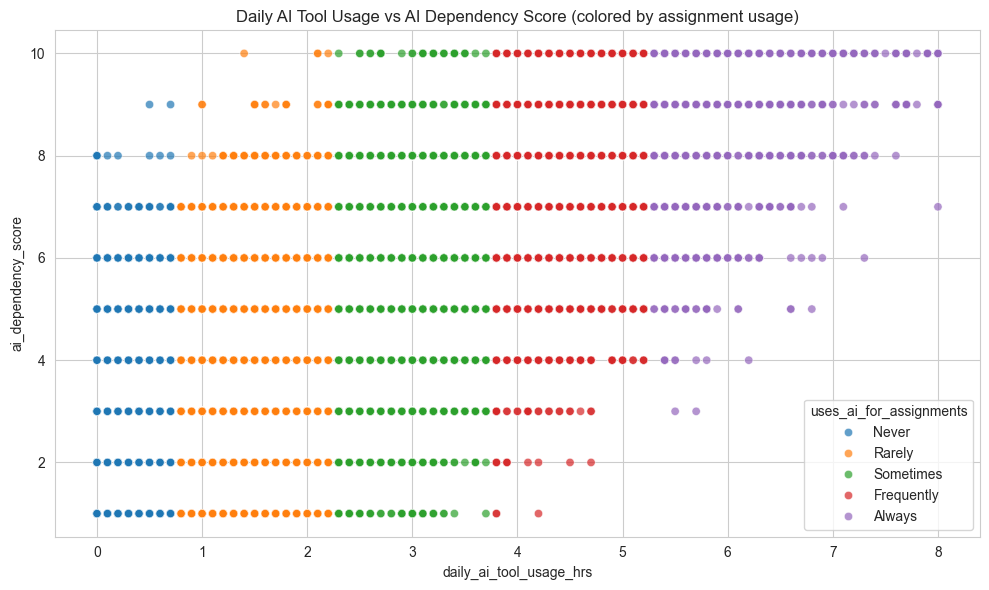

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='daily_ai_tool_usage_hrs', y='ai_dependency_score', hue='uses_ai_for_assignments', alpha=0.7)
plt.title("Daily AI Tool Usage vs AI Dependency Score (colored by assignment usage)")
plt.tight_layout()
plt.show()


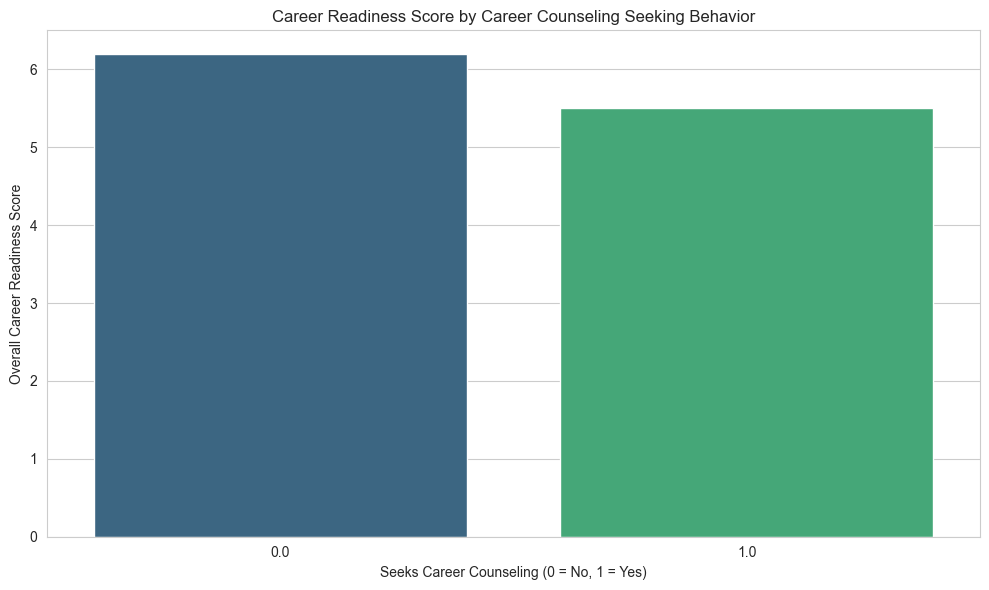

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='seeks_career_counseling', y='overall_career_readiness_score', 
            errorbar=None, hue='seeks_career_counseling', legend=False, palette='viridis')
plt.title("Career Readiness Score by Career Counseling Seeking Behavior")
plt.xlabel("Seeks Career Counseling (0 = No, 1 = Yes)")
plt.ylabel("Overall Career Readiness Score")
plt.tight_layout()
plt.show()

In [19]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return len(outliers), lower, upper

for var in key_vars:
    n_out, low, up = detect_outliers_iqr(df, var)
    print(f"{var}: {n_out} outliers (bounds: [{low:.2f}, {up:.2f}])")

ai_dependency_score: 0 outliers (bounds: [-1.50, 10.50])
placement_anxiety_score: 0 outliers (bounds: [-2.00, 14.00])
fear_of_job_loss_to_ai: 0 outliers (bounds: [0.00, 8.00])
career_clarity_score: 0 outliers (bounds: [-1.50, 10.50])
burnout_score: 0 outliers (bounds: [-0.50, 11.50])
stress_level: 46 outliers (bounds: [1.00, 9.00])
motivation_score: 0 outliers (bounds: [-1.50, 10.50])


In [20]:
df.to_csv("cleaned_student_data.csv", index=False)
print("\nEDA completed successfully.")


EDA completed successfully.
